<a href="https://colab.research.google.com/github/luciaPi/MLSS2026-generative-models/blob/main/6_Histopathology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BreaKHis: Klasifikácia (FC vs CNN) a rýchly DCGAN

Tento notebook je demo pre študentov, rozdelené na dva bloky:

1. **Klasifikácia benígne vs malígne** – porovnanie plne prepojenej siete (FC/MLP) a konvolučnej siete (CNN)
2. **Generatívny model** – jednoduchý DCGAN (32×32), nepodmienený aj podmienený triedou (benígne/malígne)

Dataset: [BreaKHis](https://www.inf.ufpr.br/vri/databases/BreaKHis_v1.tar.gz) (Breast Cancer Histopathological Database), zväčšenie **200X**.

> Poznámka: notebook je navrhnutý tak, aby rýchlo zbehol na Colab GPU (T4) – malé rozlíšenia, málo epôch. Pre reálny výskum by bolo treba viac dát, augmentácie aj dlhší tréning.


## 0. Nastavenie prostredia

In [1]:
# Over, či máme GPU (Runtime -> Change runtime type -> GPU)
import torch
print("CUDA dostupná:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Používam zariadenie:", device)


CUDA dostupná: True
Používam zariadenie: cuda


## 1. Stiahnutie datasetu

Stiahneme oficiálny archív BreaKHis (cca 4 GB komprimovaný, môže to chvíľu trvať – cca 2-5 minút na Colabe).


In [2]:
import os

DATA_DIR = "/content/BreaKHis_v1"

if not os.path.exists(DATA_DIR):
    !wget -q --show-progress -O /content/BreaKHis_v1.tar.gz http://www.inf.ufpr.br/vri/databases/BreaKHis_v1.tar.gz
    !tar -xzf /content/BreaKHis_v1.tar.gz -C /content
    print("Hotovo, dataset rozbalený.")
else:
    print("Dataset už existuje.")


/content/BreaKHis_v 100%[===================>]   3.98G  21.3MB/s    in 3m 20s  
Hotovo, dataset rozbalený.


## 2. Príprava zoznamu obrázkov (200X, benign/malignant)

BreaKHis má priečinkovú štruktúru v tvare:
`.../histology_slides/breast/{benign,malignant}/SOB/<podtyp>/<vzorka>/200X/*.png`

Prejdeme adresárovú štruktúru a vytvoríme zoznam (cesta, label) len pre zväčšenie 200X.


In [3]:
import glob
import pandas as pd

ROOT = glob.glob(f"{DATA_DIR}/**/histology_slides/breast", recursive=True)[0]

records = []
for label_name, label in [("benign", 0), ("malignant", 1)]:
    pattern = f"{ROOT}/{label_name}/**/200X/*.png"
    for path in glob.glob(pattern, recursive=True):
        records.append({"path": path, "label": label})

df = pd.DataFrame(records)
print(f"Počet obrázkov (200X): {len(df)}")
print(df["label"].value_counts().rename({0: "benign", 1: "malignant"}))
df.head()


Počet obrázkov (200X): 2013
label
malignant    1390
benign        623
Name: count, dtype: int64


,path,label
0,/content/BreaKHis_v1/histology_slides/breast/b...,0
1,/content/BreaKHis_v1/histology_slides/breast/b...,0
2,/content/BreaKHis_v1/histology_slides/breast/b...,0
3,/content/BreaKHis_v1/histology_slides/breast/b...,0
4,/content/BreaKHis_v1/histology_slides/breast/b...,0


## 3. Train/val split a Dataset/DataLoader

Bez augmentácií, len resize + normalizácia. FC aj CNN budú trénované na **rovnakom** rozlíšení (64×64), aby bolo porovnanie fér.


In [4]:
from sklearn.model_selection import train_test_split
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

train_df, val_df = train_test_split(
    df, test_size=0.2, stratify=df["label"], random_state=42
)
print("Train:", len(train_df), "Val:", len(val_df))

IMG_SIZE = 64

transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),  # do <0,1>
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),  # do <-1,1>
])

class BreakHisDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        img = self.transform(img)
        label = torch.tensor(row["label"], dtype=torch.long)
        return img, label

train_ds = BreakHisDataset(train_df, transform)
val_ds = BreakHisDataset(val_df, transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=2)


Train: 1610 Val: 403


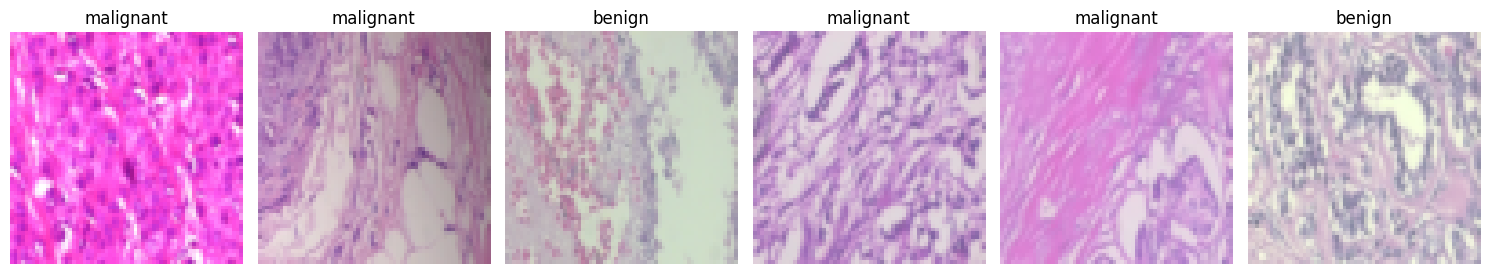

In [5]:
# Rýchla vizuálna kontrola pár vzoriek
import matplotlib.pyplot as plt

def denorm(img_tensor):
    img = img_tensor.permute(1, 2, 0).numpy()
    return (img * 0.5) + 0.5

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i in range(6):
    img, label = train_ds[i]
    axes[i].imshow(denorm(img))
    axes[i].set_title("benign" if label == 0 else "malignant")
    axes[i].axis("off")
plt.tight_layout()
plt.show()


---
# Blok 1: Klasifikácia — FC (MLP) vs CNN

Obe siete riešia rovnaký binárny problém (benígne = 0, malígne = 1) na rovnakých 64×64 obrázkoch.


In [6]:
import torch.nn as nn
import torch.nn.functional as F

class FCNet(nn.Module):
    """Naivný prístup: obrázok sa 'sploští' na vektor, priestorová informácia sa stráca."""
    def __init__(self, img_size=64, num_classes=2):
        super().__init__()
        in_features = img_size * img_size * 3
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)


class ConvNet(nn.Module):
    """Jednoduchý CNN, ktorý využíva priestorovú štruktúru obrázka."""
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 64 -> 32
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32 -> 16
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 16 -> 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


fc_params = sum(p.numel() for p in FCNet().parameters())
cnn_params = sum(p.numel() for p in ConvNet().parameters())
print(f"FCNet parametrov:  {fc_params:,}")
print(f"ConvNet parametrov: {cnn_params:,}")


FCNet parametrov:  6,357,890
ConvNet parametrov: 1,142,210


In [7]:
def train_model(model, train_loader, val_loader, epochs=8, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
        train_loss = running_loss / len(train_loader.dataset)

        model.eval()
        val_loss, correct = 0.0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                out = model(imgs)
                loss = criterion(out, labels)
                val_loss += loss.item() * imgs.size(0)
                correct += (out.argmax(1) == labels).sum().item()
        val_loss /= len(val_loader.dataset)
        val_acc = correct / len(val_loader.dataset)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        print(f"[{model.__class__.__name__}] epoch {epoch+1}/{epochs} "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    return history

fc_model = FCNet()
fc_history = train_model(fc_model, train_loader, val_loader, epochs=8)


[FCNet] epoch 1/8 train_loss=0.6754 val_loss=0.4145 val_acc=0.8610
[FCNet] epoch 2/8 train_loss=0.4978 val_loss=0.3880 val_acc=0.8412
[FCNet] epoch 3/8 train_loss=0.4720 val_loss=0.3931 val_acc=0.8635
[FCNet] epoch 4/8 train_loss=0.4727 val_loss=0.4033 val_acc=0.8288
[FCNet] epoch 5/8 train_loss=0.4440 val_loss=0.3769 val_acc=0.8536
[FCNet] epoch 6/8 train_loss=0.4365 val_loss=0.3709 val_acc=0.8462
[FCNet] epoch 7/8 train_loss=0.4196 val_loss=0.3698 val_acc=0.8710
[FCNet] epoch 8/8 train_loss=0.3895 val_loss=0.3817 val_acc=0.8710


In [8]:
cnn_model = ConvNet()
cnn_history = train_model(cnn_model, train_loader, val_loader, epochs=8)


[ConvNet] epoch 1/8 train_loss=0.5264 val_loss=0.3861 val_acc=0.8660
[ConvNet] epoch 2/8 train_loss=0.4318 val_loss=0.3555 val_acc=0.8511
[ConvNet] epoch 3/8 train_loss=0.3740 val_loss=0.3583 val_acc=0.8412
[ConvNet] epoch 4/8 train_loss=0.3729 val_loss=0.3285 val_acc=0.8983
[ConvNet] epoch 5/8 train_loss=0.3668 val_loss=0.2880 val_acc=0.8958
[ConvNet] epoch 6/8 train_loss=0.3269 val_loss=0.2801 val_acc=0.8908
[ConvNet] epoch 7/8 train_loss=0.3167 val_loss=0.2532 val_acc=0.8933
[ConvNet] epoch 8/8 train_loss=0.2885 val_loss=0.3046 val_acc=0.9032


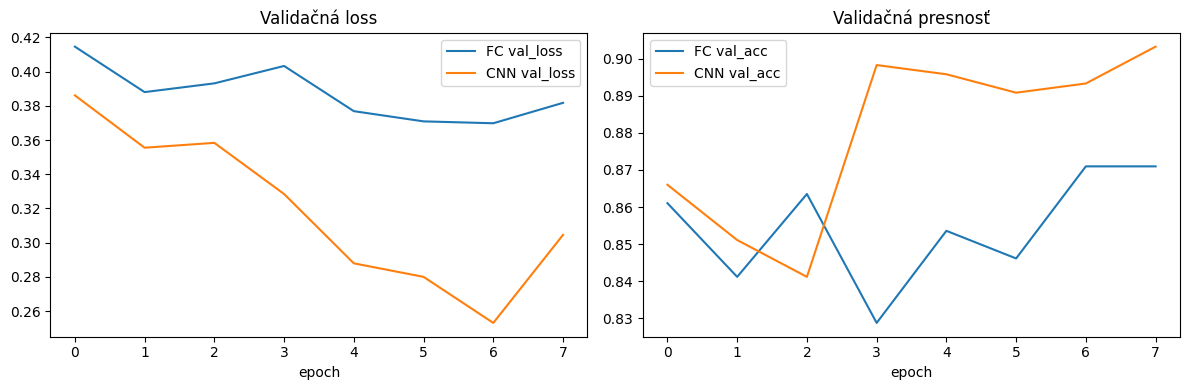

Finálna presnosť FC:  0.8710
Finálna presnosť CNN: 0.9032


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fc_history["val_loss"], label="FC val_loss")
axes[0].plot(cnn_history["val_loss"], label="CNN val_loss")
axes[0].set_title("Validačná loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(fc_history["val_acc"], label="FC val_acc")
axes[1].plot(cnn_history["val_acc"], label="CNN val_acc")
axes[1].set_title("Validačná presnosť")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Finálna presnosť FC:  {fc_history['val_acc'][-1]:.4f}")
print(f"Finálna presnosť CNN: {cnn_history['val_acc'][-1]:.4f}")


### Vizualizácia predikcií — náhodné snímky

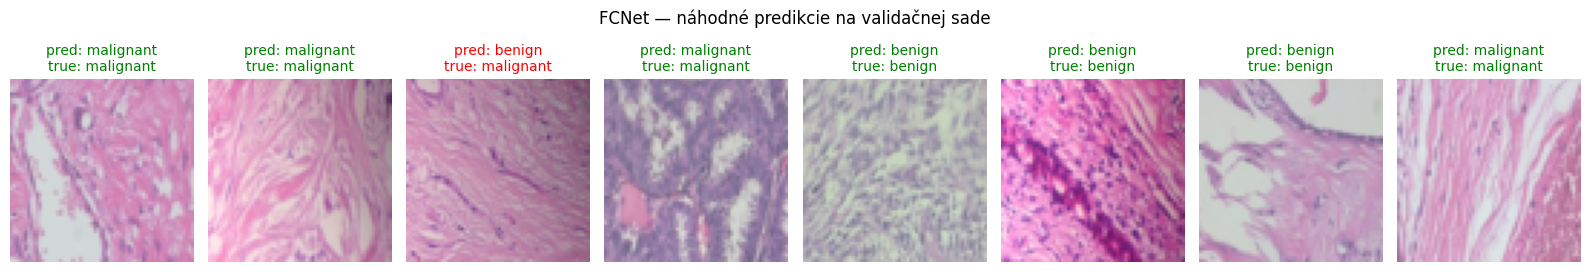

In [10]:
import random

def show_predictions(model, dataset, n=8, title=""):
    model.eval()
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(1, n, figsize=(2 * n, 3))
    class_names = {0: "benign", 1: "malignant"}

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            img, label = dataset[idx]
            input_tensor = img.unsqueeze(0).to(device)
            pred = model(input_tensor).argmax(1).item()

            ax.imshow(denorm(img))
            true_name = class_names[label.item()]
            pred_name = class_names[pred]
            color = "green" if pred == label.item() else "red"
            ax.set_title(f"pred: {pred_name}\ntrue: {true_name}", color=color, fontsize=10)
            ax.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

show_predictions(fc_model, val_ds, n=8, title="FCNet — náhodné predikcie na validačnej sade")


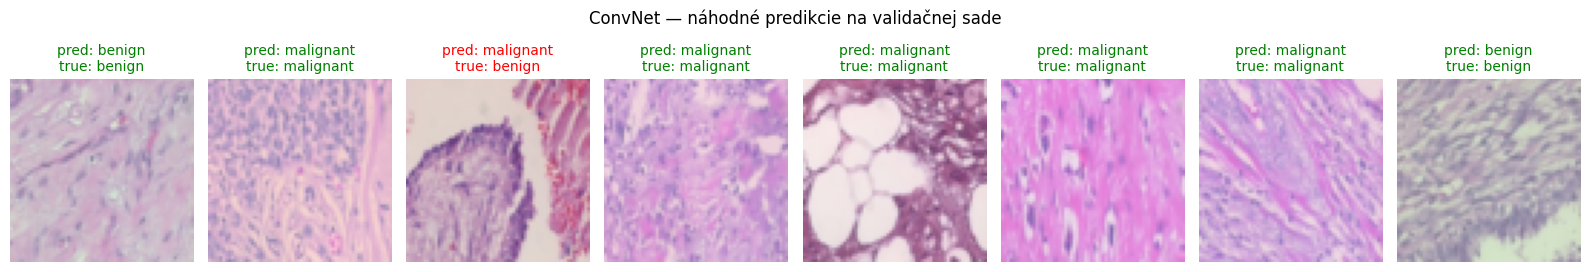

In [11]:
show_predictions(cnn_model, val_ds, n=8, title="ConvNet — náhodné predikcie na validačnej sade")


---
# Blok 2: Generatívny model — DCGAN (32×32)

BreaKHis má na tréning GAN-u málo obrázkov (~7 900), preto pre tento blok použijeme väčší verejný dataset — **PatchCamelyon (PCam)**: 327 680 histopatologických snímok (96×96, lymfatické uzliny), binárny label = prítomnosť/neprítomnosť metastázy. Je priamo zabudovaný v `torchvision`, takže sa stiahne jedným príkazom.

Aby tréning bežal rýchlo, zmenšíme obrázky na 32×32 a použijeme malý počet epôch. Najprv **nepodmienený** DCGAN, potom **podmienený (conditional)** variant, ktorý vie generovať osobitne snímky bez metastázy a osobitne s metastázou.


In [16]:
!pip install -q datasets

from datasets import load_dataset

# Stiahneme len prvých 20 000 obrázkov trénovacieho splitu (rýchlejšie pre demo)
pcam_hf = load_dataset("1aurent/PatchCamelyon", split="train[:20000]")
print(pcam_hf)

GAN_IMG_SIZE = 32
LATENT_DIM = 100

gan_transform = T.Compose([
    T.Resize((GAN_IMG_SIZE, GAN_IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
])

class HFImageDataset(Dataset):
    """Obalí HuggingFace dataset do bežného PyTorch Dataset rozhrania."""
    def __init__(self, hf_dataset, transform):
        self.ds = hf_dataset
        self.transform = transform

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        img = item["image"].convert("RGB")
        label = int(item["label"])
        img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

pcam_train = HFImageDataset(pcam_hf, gan_transform)
gan_loader = DataLoader(pcam_train, batch_size=128, shuffle=True, num_workers=2, drop_last=True)

print("Počet obrázkov pre GAN (PCam subset):", len(pcam_train))

README.md:   0%|          | 0.00/4.42k [00:00<?, ?B/s]

data/train-00000-of-00013-4717c3cf92578c(…): reconstructing file:   0%|          |  0.00B /  471MB            

data/train-00000-of-00013-4717c3cf92578c(…): downloading bytes:           |  0.00B            

data/train-00001-of-00013-549914845b4273(…): reconstructing file:   0%|          |  0.00B /  471MB            

data/train-00001-of-00013-549914845b4273(…): downloading bytes:           |  0.00B            

...

data/test-00001-of-00002-3bfa172e8818685(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/262144 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/32768 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/32768 [00:00<?, ? examples/s]

Dataset({
    features: ['image', 'label'],
    num_rows: 20000
})
Počet obrázkov pre GAN (PCam subset): 20000


### 2.1 Nepodmienený DCGAN

In [17]:
class Generator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, feature_maps=64):
        super().__init__()
        self.net = nn.Sequential(
            # latent -> 4x4
            nn.ConvTranspose2d(latent_dim, feature_maps * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_maps * 4), nn.ReLU(True),
            # 4x4 -> 8x8
            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2), nn.ReLU(True),
            # 8x8 -> 16x16
            nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps), nn.ReLU(True),
            # 16x16 -> 32x32
            nn.ConvTranspose2d(feature_maps, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, feature_maps=64):
        super().__init__()
        self.net = nn.Sequential(
            # 32x32 -> 16x16
            nn.Conv2d(3, feature_maps, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 16x16 -> 8x8
            nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2), nn.LeakyReLU(0.2, inplace=True),
            # 8x8 -> 4x4
            nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 4), nn.LeakyReLU(0.2, inplace=True),
            # 4x4 -> 1x1
            nn.Conv2d(feature_maps * 4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)


def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [18]:
import torchvision.utils as vutils

def train_dcgan(dataloader, epochs=15, latent_dim=LATENT_DIM, label_getter=None, num_classes=None):
    """label_getter: ak je zadané, trénuje sa podmienený GAN (viď 2.2)."""
    conditional = label_getter is not None

    if conditional:
        gen = CondGenerator(latent_dim, num_classes).to(device)
        disc = CondDiscriminator(num_classes).to(device)
    else:
        gen = Generator(latent_dim).to(device)
        disc = Discriminator().to(device)
    gen.apply(weights_init)
    disc.apply(weights_init)

    criterion = nn.BCEWithLogitsLoss()
    opt_g = torch.optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))

    fixed_noise = torch.randn(16, latent_dim, 1, 1, device=device)
    fixed_labels = None
    if conditional:
        fixed_labels = torch.arange(num_classes).repeat(16 // num_classes + 1)[:16].to(device)

    snapshots = []

    for epoch in range(epochs):
        for imgs, labels in dataloader:
            imgs = imgs.to(device)
            b = imgs.size(0)
            real_target = torch.ones(b, device=device)
            fake_target = torch.zeros(b, device=device)
            noise = torch.randn(b, latent_dim, 1, 1, device=device)

            if conditional:
                labels = labels.to(device).long()

            # --- Diskriminátor ---
            opt_d.zero_grad()
            if conditional:
                out_real = disc(imgs, labels)
            else:
                out_real = disc(imgs)
            loss_real = criterion(out_real, real_target)

            if conditional:
                fake = gen(noise, labels)
                out_fake = disc(fake.detach(), labels)
            else:
                fake = gen(noise)
                out_fake = disc(fake.detach())
            loss_fake = criterion(out_fake, fake_target)

            loss_d = loss_real + loss_fake
            loss_d.backward()
            opt_d.step()

            # --- Generátor ---
            opt_g.zero_grad()
            if conditional:
                out_fake_for_g = disc(fake, labels)
            else:
                out_fake_for_g = disc(fake)
            loss_g = criterion(out_fake_for_g, real_target)
            loss_g.backward()
            opt_g.step()

        print(f"epoch {epoch+1}/{epochs}  loss_d={loss_d.item():.3f}  loss_g={loss_g.item():.3f}")

        gen.eval()
        with torch.no_grad():
            if conditional:
                sample = gen(fixed_noise, fixed_labels).cpu()
            else:
                sample = gen(fixed_noise).cpu()
        gen.train()
        snapshots.append(sample)

    return gen, disc, snapshots


def show_snapshot(sample, nrow=4, title=""):
    grid = vutils.make_grid(sample, nrow=nrow, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(6, 6))
    plt.axis("off")
    plt.title(title)
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.show()


epoch 1/50  loss_d=0.507  loss_g=5.233
epoch 2/50  loss_d=0.417  loss_g=3.216
epoch 3/50  loss_d=0.446  loss_g=4.338
epoch 4/50  loss_d=0.317  loss_g=4.010
epoch 5/50  loss_d=1.121  loss_g=2.389
epoch 6/50  loss_d=0.443  loss_g=3.812
epoch 7/50  loss_d=0.542  loss_g=4.277
epoch 8/50  loss_d=0.292  loss_g=5.052
epoch 9/50  loss_d=0.514  loss_g=4.627
epoch 10/50  loss_d=0.650  loss_g=4.405
epoch 11/50  loss_d=0.703  loss_g=4.457
epoch 12/50  loss_d=0.934  loss_g=4.713
epoch 13/50  loss_d=0.573  loss_g=3.833
epoch 14/50  loss_d=0.841  loss_g=2.052
epoch 15/50  loss_d=0.920  loss_g=2.994
epoch 16/50  loss_d=0.867  loss_g=2.628
epoch 17/50  loss_d=0.594  loss_g=2.614
epoch 18/50  loss_d=0.760  loss_g=2.608
epoch 19/50  loss_d=0.771  loss_g=1.830
epoch 20/50  loss_d=0.728  loss_g=2.937
epoch 21/50  loss_d=1.518  loss_g=4.187
epoch 22/50  loss_d=0.839  loss_g=1.746
epoch 23/50  loss_d=1.081  loss_g=1.325
epoch 24/50  loss_d=1.352  loss_g=3.017
epoch 25/50  loss_d=0.536  loss_g=2.727
epoch 26/

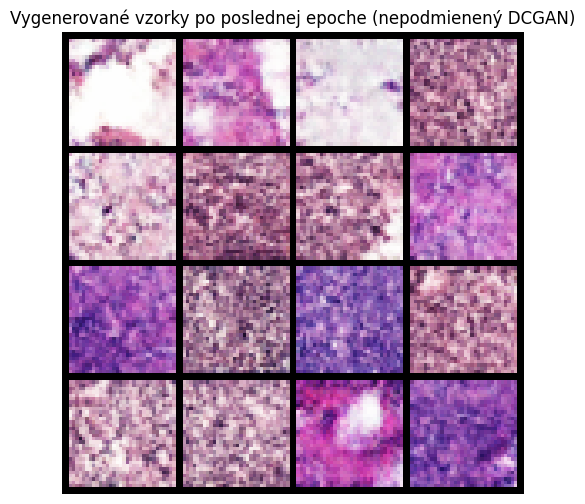

In [23]:
gen, disc, snapshots = train_dcgan(gan_loader, epochs=50)
show_snapshot(snapshots[-1], title="Vygenerované vzorky po poslednej epoche (nepodmienený DCGAN)")


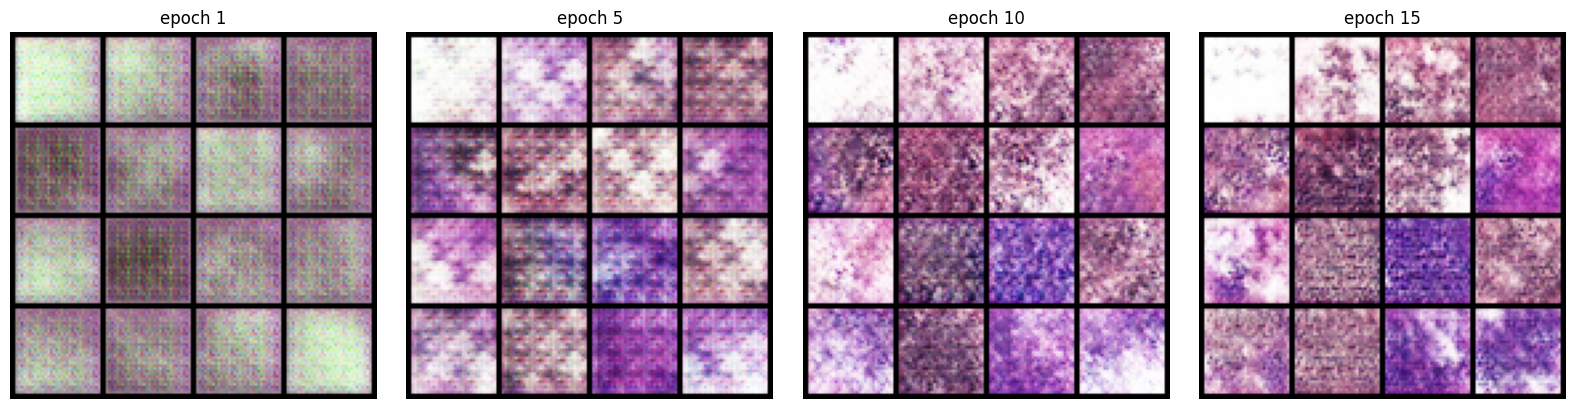

In [24]:
# Vývoj kvality generovania počas tréningu (napr. epochy 1, 5, 10, 15)
idxs = [0, 4, 9, min(14, len(snapshots) - 1)]
fig, axes = plt.subplots(1, len(idxs), figsize=(16, 4))
for ax, idx in zip(axes, idxs):
    grid = vutils.make_grid(snapshots[idx], nrow=4, normalize=True, value_range=(-1, 1))
    ax.imshow(grid.permute(1, 2, 0).numpy())
    ax.set_title(f"epoch {idx+1}")
    ax.axis("off")
plt.tight_layout()
plt.show()


### 2.2 Podmienený (conditional) DCGAN — bez metastázy vs s metastázou

Rovnaká architektúra, ale label (PCam: 0 = bez metastázy, 1 = metastáza) sa vloží ako dodatočný vstup (embedding) do generátora aj diskriminátora, takže vieme generovať cielene snímky jednej alebo druhej triedy.

In [21]:
NUM_CLASSES = 2

class CondGenerator(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, num_classes=NUM_CLASSES, feature_maps=64):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, latent_dim)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim * 2, feature_maps * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(feature_maps * 4), nn.ReLU(True),
            nn.ConvTranspose2d(feature_maps * 4, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2), nn.ReLU(True),
            nn.ConvTranspose2d(feature_maps * 2, feature_maps, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps), nn.ReLU(True),
            nn.ConvTranspose2d(feature_maps, 3, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z, labels):
        label_vec = self.label_emb(labels).unsqueeze(-1).unsqueeze(-1)  # (b, latent_dim, 1, 1)
        x = torch.cat([z, label_vec], dim=1)
        return self.net(x)


class CondDiscriminator(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, feature_maps=64, img_size=GAN_IMG_SIZE):
        super().__init__()
        self.img_size = img_size
        self.label_emb = nn.Embedding(num_classes, img_size * img_size)
        self.net = nn.Sequential(
            nn.Conv2d(4, feature_maps, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_maps, feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 2), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_maps * 2, feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(feature_maps * 4), nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(feature_maps * 4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x, labels):
        label_map = self.label_emb(labels).view(-1, 1, self.img_size, self.img_size)
        x = torch.cat([x, label_map], dim=1)
        return self.net(x).view(-1)


epoch 1/50  loss_d=0.401  loss_g=3.892
epoch 2/50  loss_d=0.143  loss_g=3.838
epoch 3/50  loss_d=0.324  loss_g=5.611
epoch 4/50  loss_d=0.115  loss_g=5.265
epoch 5/50  loss_d=1.132  loss_g=2.264
epoch 6/50  loss_d=0.242  loss_g=4.313
epoch 7/50  loss_d=0.545  loss_g=2.615
epoch 8/50  loss_d=0.479  loss_g=1.968
epoch 9/50  loss_d=0.342  loss_g=3.457
epoch 10/50  loss_d=0.767  loss_g=2.230
epoch 11/50  loss_d=0.400  loss_g=2.977
epoch 12/50  loss_d=1.015  loss_g=2.277
epoch 13/50  loss_d=1.709  loss_g=1.801
epoch 14/50  loss_d=1.030  loss_g=2.268
epoch 15/50  loss_d=0.750  loss_g=1.638
epoch 16/50  loss_d=1.257  loss_g=1.506
epoch 17/50  loss_d=0.844  loss_g=2.411
epoch 18/50  loss_d=1.327  loss_g=1.271
epoch 19/50  loss_d=0.915  loss_g=2.756
epoch 20/50  loss_d=0.696  loss_g=3.844
epoch 21/50  loss_d=0.561  loss_g=3.330
epoch 22/50  loss_d=0.749  loss_g=3.310
epoch 23/50  loss_d=0.880  loss_g=2.761
epoch 24/50  loss_d=0.790  loss_g=2.498
epoch 25/50  loss_d=1.164  loss_g=4.424
epoch 26/

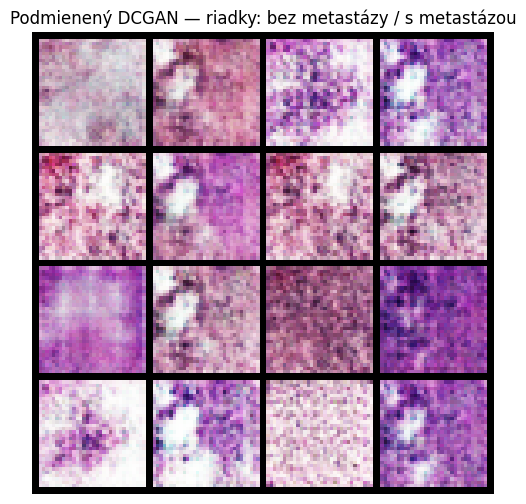

In [25]:
cond_gen, cond_disc, cond_snapshots = train_dcgan(
    gan_loader, epochs=50, label_getter=True, num_classes=NUM_CLASSES
)
show_snapshot(cond_snapshots[-1], title="Podmienený DCGAN — riadky: bez metastázy / s metastázou")


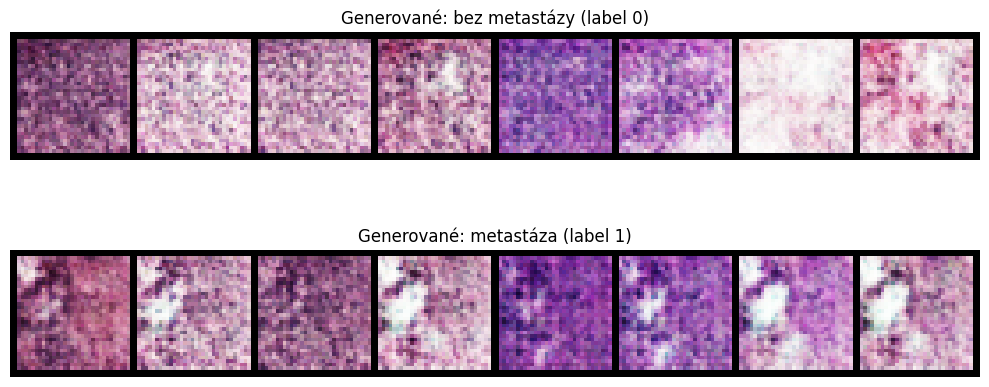

In [26]:
# Explicitné porovnanie: vygeneruj len snímky bez metastázy a len s metastázou
cond_gen.eval()
with torch.no_grad():
    noise = torch.randn(8, LATENT_DIM, 1, 1, device=device)
    negative_labels = torch.zeros(8, dtype=torch.long, device=device)
    positive_labels = torch.ones(8, dtype=torch.long, device=device)
    negative_samples = cond_gen(noise, negative_labels).cpu()
    positive_samples = cond_gen(noise, positive_labels).cpu()

fig, axes = plt.subplots(2, 1, figsize=(10, 5))
axes[0].imshow(vutils.make_grid(negative_samples, nrow=8, normalize=True, value_range=(-1, 1)).permute(1, 2, 0))
axes[0].set_title("Generované: bez metastázy (label 0)")
axes[0].axis("off")
axes[1].imshow(vutils.make_grid(positive_samples, nrow=8, normalize=True, value_range=(-1, 1)).permute(1, 2, 0))
axes[1].set_title("Generované: metastáza (label 1)")
axes[1].axis("off")
plt.tight_layout()
plt.show()


---
## Zhrnutie a nápady na rozšírenie

- **Blok 1:** skúste zmeniť rozlíšenie (napr. 32×32 vs 128×128) a pozrite, ako sa mení rozdiel medzi FC a CNN.
- **Blok 1:** pridajte augmentácie (flip, rotácie) a porovnajte robustnosť.
- **Blok 2:** predĺžte tréning DCGAN (viac epôch) a sledujte, ako sa zlepšuje ostrosť detailov.
- **Blok 2:** skúste iné zväčšenia (40X, 400X) alebo iné rozlíšenie (64×64) — všimnite si trade-off medzi kvalitou a rýchlosťou tréningu.

Vytvorené s použitím Claude AI.
